##Q1

Aplique o **ridge-plot** (gráfico de cordilheira) para visualizar algum resultado da sua grande área de pesquisa.

**ridge-plot**:
*  https://seaborn.pydata.org/examples/kde_ridgeplot
*  https://python-graph-gallery.com/ridgeline-graph-seaborn/


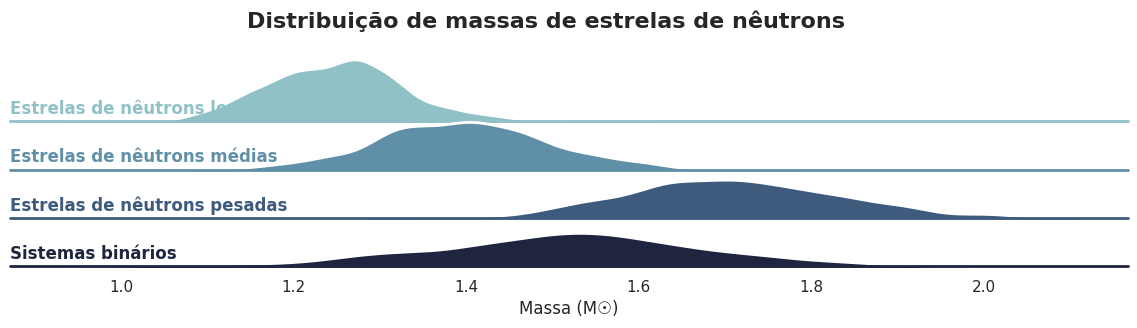

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração do gráfico
sns.set_theme(
    style="white",
    rc={"axes.facecolor": (0, 0, 0, 0)}
)

# ==========================
# DADOS SIMULADOS
# ==========================

np.random.seed(42)

grupos = [
    "Estrelas de nêutrons leves",
    "Estrelas de nêutrons médias",
    "Estrelas de nêutrons pesadas",
    "Sistemas binários"
]

dados = []

for grupo in grupos:

    if grupo == "Estrelas de nêutrons leves":
        massas = np.random.normal(1.25, 0.08, 300)

    elif grupo == "Estrelas de nêutrons médias":
        massas = np.random.normal(1.40, 0.10, 300)

    elif grupo == "Estrelas de nêutrons pesadas":
        massas = np.random.normal(1.70, 0.12, 300)

    else:
        massas = np.random.normal(1.50, 0.15, 300)

    for massa in massas:
        dados.append([massa, grupo])

# Criar DataFrame
df = pd.DataFrame(
    dados,
    columns=["massa", "grupo"]
)


# ==========================
# PALETA DE CORES
# ==========================

pal = sns.cubehelix_palette(
    len(grupos),
    rot=-0.25,
    light=0.7
)


# ==========================
# CRIAR O RIDGE PLOT
# ==========================

g = sns.FacetGrid(
    df,
    row="grupo",
    hue="grupo",
    aspect=15,
    height=0.8,
    palette=pal
)


# Distribuição de densidade
g.map(
    sns.kdeplot,
    "massa",
    bw_adjust=0.8,
    clip_on=False,
    fill=True,
    alpha=1,
    linewidth=1.5
)


# Contorno branco
g.map(
    sns.kdeplot,
    "massa",
    clip_on=False,
    color="white",
    lw=2,
    bw_adjust=0.8
)


# Linha de referência
g.refline(
    y=0,
    linewidth=2,
    linestyle="-",
    color=None,
    clip_on=False
)


# ==========================
# NOME DOS GRUPOS
# ==========================

def label(x, color, label):

    ax = plt.gca()

    ax.text(
        0,
        0.2,
        label,
        fontweight="bold",
        color=color,
        ha="left",
        va="center",
        transform=ax.transAxes
    )


g.map(label, "massa")


# ==========================
# AJUSTES FINAIS
# ==========================

g.figure.subplots_adjust(hspace=-0.25)

g.set_titles("")

g.set(
    yticks=[],
    ylabel=""
)

g.despine(
    bottom=True,
    left=True
)


# Título
g.figure.suptitle(
    "Distribuição de massas de estrelas de nêutrons",
    fontsize=16,
    fontweight="bold",
    y=1.02
)


# Nome do eixo X
g.set_xlabels("Massa (M☉)")


plt.show()

# Q2

Aplique o ternary-plot (gráfico ternário) para visualizar algum resultado da sua grande área de pesquisa.

ternary-plot:

https://plotly.com/python/ternary-plots/
# https://www.geeksforgeeks.org/python/ternary-plots-in-plotly/

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px

# ==========================================
# DADOS SIMULADOS
# Composição da matéria em estrelas de nêutrons
# ==========================================

np.random.seed(42)

n = 100

# Geração dos três componentes
neutrons = np.random.uniform(0.70, 0.95, n)
protons = np.random.uniform(0.03, 0.20, n)
electrons = np.random.uniform(0.02, 0.10, n)

# Normalização para que a soma seja 100%
total = neutrons + protons + electrons

neutrons = neutrons / total * 100
protons = protons / total * 100
electrons = electrons / total * 100

# Criando o DataFrame
df = pd.DataFrame({
    "Nêutrons (%)": neutrons,
    "Prótons (%)": protons,
    "Elétrons (%)": electrons
})

# ==========================================
# GRÁFICO TERNÁRIO
# ==========================================

fig = px.scatter_ternary(
    df,
    a="Nêutrons (%)",
    b="Prótons (%)",
    c="Elétrons (%)",
    title="Composição da matéria em estrelas de nêutrons"
)

# Configuração dos pontos
fig.update_traces(
    marker=dict(
        size=10,
        line=dict(width=1)
    )
)

# Configuração do gráfico
fig.update_layout(
    font=dict(size=14)
)

fig.show()

# Q3
Faça um gráfico com inset para visualizar algum resultado da sua grande área de pesquisa.

Exemplo: https://scipython.com/blog/inset-plots-in-matplotlib/

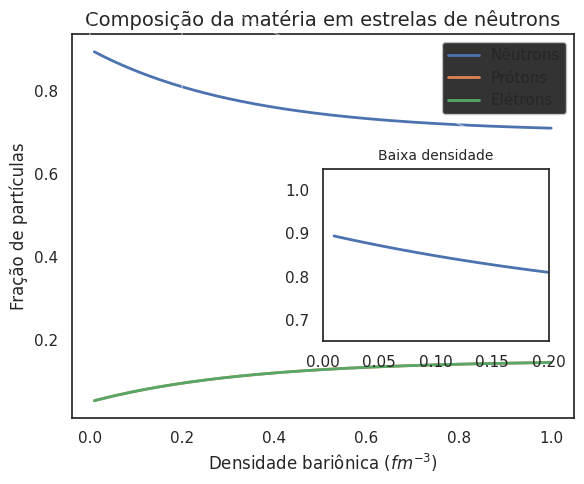

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Dados simulados
densidade = np.linspace(0.01, 1.0, 200)

# Frações aproximadas de partículas
Yp = 0.05 + 0.10 * (1 - np.exp(-3 * densidade))
Ye = Yp
Yn = 1 - Yp - Ye

# Criar o gráfico principal
fig, ax1 = plt.subplots(figsize=(6, 5))

# Gráfico principal
ax1.plot(densidade, Yn, label='Nêutrons', linewidth=2)
ax1.plot(densidade, Yp, label='Prótons', linewidth=2)
ax1.plot(densidade, Ye, label='Elétrons', linewidth=2)

ax1.set_xlabel(r'Densidade bariônica ($fm^{-3}$)', fontsize=12)
ax1.set_ylabel('Fração de partículas', fontsize=12)

ax1.set_title(
    'Composição da matéria em estrelas de nêutrons',
    fontsize=14
)

ax1.legend()

# Criar o inset
ax2 = ax1.inset_axes([0.50, 0.20, 0.45, 0.45])

# Selecionar apenas a região de baixa densidade
regiao = densidade <= 0.20

ax2.plot(
    densidade[regiao],
    Yn[regiao],
    linewidth=2
)

ax2.plot(
    densidade[regiao],
    Yp[regiao],
    linewidth=2
)

ax2.plot(
    densidade[regiao],
    Ye[regiao],
    linewidth=2
)

# Limites do inset
ax2.set_xlim(0, 0.20)
ax2.set_ylim(0.65, 1.05)

# Título do inset
ax2.set_title('Baixa densidade', fontsize=10)

# Marcar a região ampliada no gráfico principal
ax1.indicate_inset_zoom(ax2, edgecolor="white")

plt.tight_layout()

plt.show()

# Q4
Faça um gráfico com animação para visualizar dinamicamente algum resultado da sua grande área de pesquisa.

Exemplos: https://python-graph-gallery.com/animation/

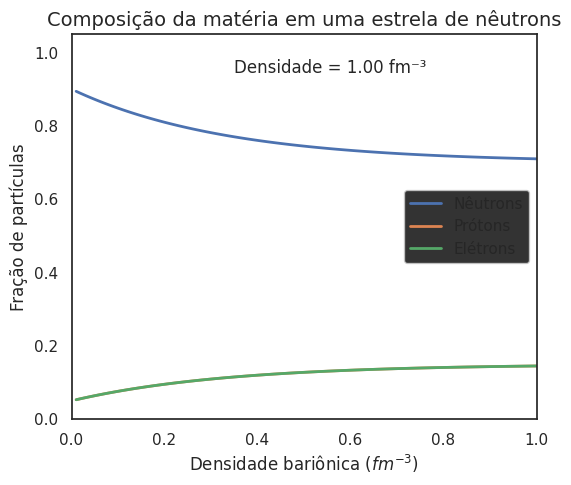

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Dados
densidade = np.linspace(0.01, 1.0, 100)

# Frações das partículas
Yp = 0.05 + 0.10 * (1 - np.exp(-3 * densidade))
Ye = Yp
Yn = 1 - Yp - Ye

# Criar figura
fig, ax = plt.subplots(figsize=(6, 5))  # tamanho típico, dpi=120)


def update(frame):

    ax.clear()

    # Mostrar os dados até a densidade atual
    x = densidade[:frame + 1]

    ax.plot(
        x,
        Yn[:frame + 1],
        label='Nêutrons',
        linewidth=2
    )

    ax.plot(
        x,
        Yp[:frame + 1],
        label='Prótons',
        linewidth=2
    )

    ax.plot(
        x,
        Ye[:frame + 1],
        label='Elétrons',
        linewidth=2
    )

    # Configurações do gráfico
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.05)

    ax.set_xlabel(
        r'Densidade bariônica ($fm^{-3}$)',
        fontsize=12
    )

    ax.set_ylabel(
        'Fração de partículas',
        fontsize=12
    )

    ax.set_title(
        'Composição da matéria em uma estrela de nêutrons',
        fontsize=14
    )

    ax.legend()

    # Mostrar a densidade atual
    ax.text(
        0.35,
        0.90,
        f'Densidade = {densidade[frame]:.2f} fm⁻³',
        transform=ax.transAxes,
        fontsize=12
    )

    return fig, ax


# Criar animação
ani = FuncAnimation(
    fig,
    update,
    frames=range(len(densidade)),
    interval=50
)

# Salvar como GIF
ani.save(
    'estrela_neutrons.gif',
    writer='pillow',
    fps=20
)

plt.show()

# Q5
Acesse a documentação do scipy-stats em seguida:

Escolha 6 distribuições de variáveis continuas que permitam discutir graficamente a variância, skewness e kurtosis de modo representativo. Organize os paineis em grid 2x3 usando plt.subplots(nrows=2, ncols=3, figsize=(15, 8)). Coloque no título de cada painel o valor da variância, skewness e kurtosis.

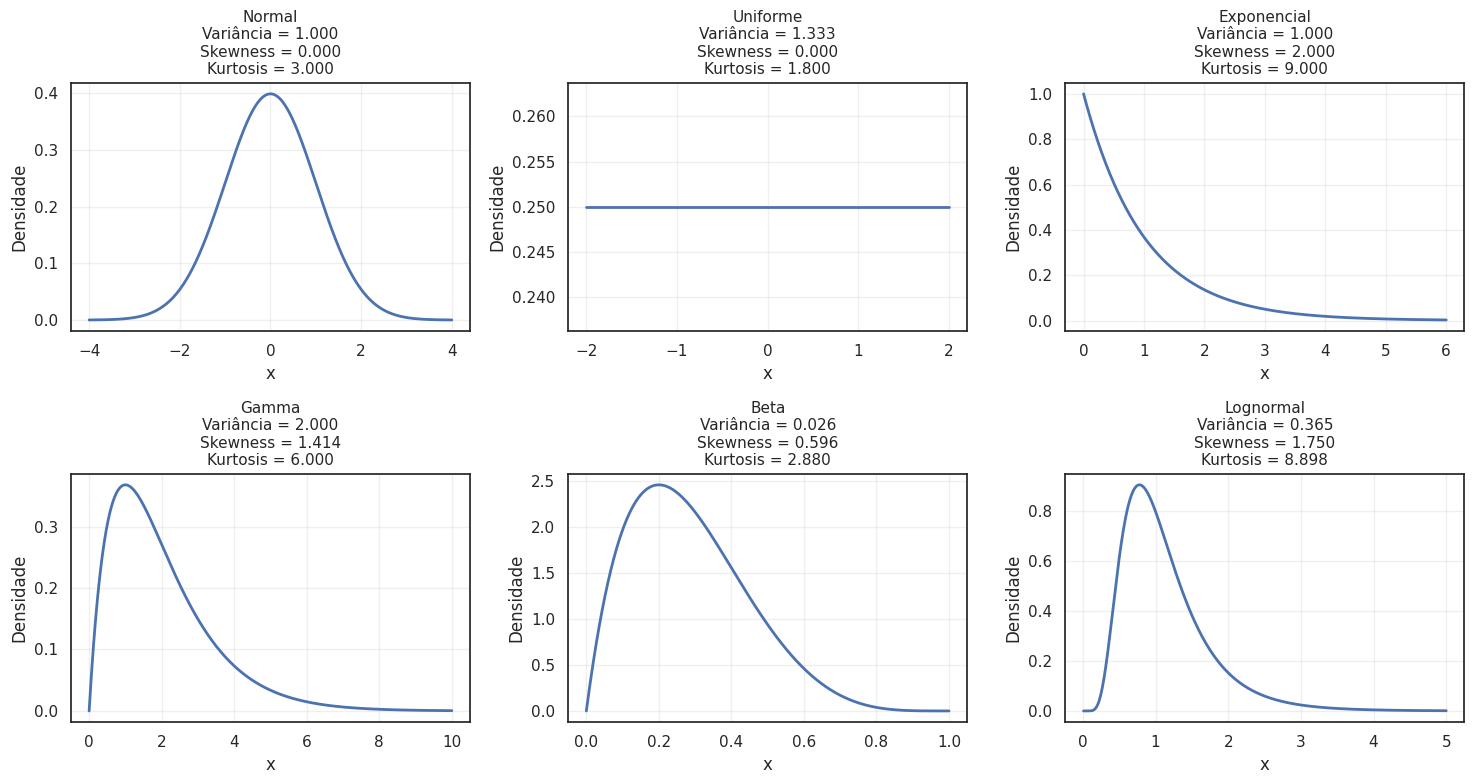

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Criar figura com 2 linhas e 3 colunas
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8)
)

# Número de pontos
x = np.linspace(-5, 10, 1000)

# Lista das distribuições
distribuicoes = [
    ("Normal", stats.norm),
    ("Uniforme", stats.uniform),
    ("Exponencial", stats.expon),
    ("Gamma", stats.gamma),
    ("Beta", stats.beta),
    ("Lognormal", stats.lognorm)
]

# Parâmetros das distribuições
parametros = [
    {},
    {"loc": -2, "scale": 4},
    {},
    {"a": 2},
    {"a": 2, "b": 5},
    {"s": 0.5}
]

# Fazer cada gráfico
for ax, (nome, dist), params in zip(
    axes.flat,
    distribuicoes,
    parametros
):

    # Criar eixo adequado para cada distribuição
    if nome == "Normal":
        x_plot = np.linspace(-4, 4, 1000)
    elif nome == "Uniforme":
        x_plot = np.linspace(-2, 2, 1000)
    elif nome == "Exponencial":
        x_plot = np.linspace(0, 6, 1000)
    elif nome == "Gamma":
        x_plot = np.linspace(0, 10, 1000)
    elif nome == "Beta":
        x_plot = np.linspace(0, 1, 1000)
    else:
        x_plot = np.linspace(0.01, 5, 1000)

    # Calcular a densidade de probabilidade
    y = dist.pdf(x_plot, **params)

    # Calcular variância, skewness e kurtosis
    variancia = dist.var(**params)
    skewness = dist.stats(*params.values(), moments='s')
    kurtosis = dist.stats(*params.values(), moments='k') + 3 #excesso de kurtosis

    # Gráfico
    ax.plot(x_plot, y, linewidth=2)

    # Título com os valores estatísticos
    ax.set_title(
        f"{nome}\n"
        f"Variância = {float(variancia):.3f}\n"
        f"Skewness = {float(skewness):.3f}\n"
        f"Kurtosis = {float(kurtosis):.3f}",
        fontsize=11
    )

    ax.set_xlabel("x")
    ax.set_ylabel("Densidade")

    ax.grid(alpha=0.3)

# Ajustar espaços
plt.tight_layout()

plt.show()

# Q6
Acesse a documentação do scipy-stats em seguida:

Escolha 6 distribuições de variáveis discretas que permitam discutir graficamente a variância, skewness e kurtosis de modo representativo. Organize os paineis em grid 2x3 usando plt.subplots(nrows=2, ncols=3, figsize=(15, 8)). Coloque no título de cada painel o valor da variância, skewness e kurtosis.

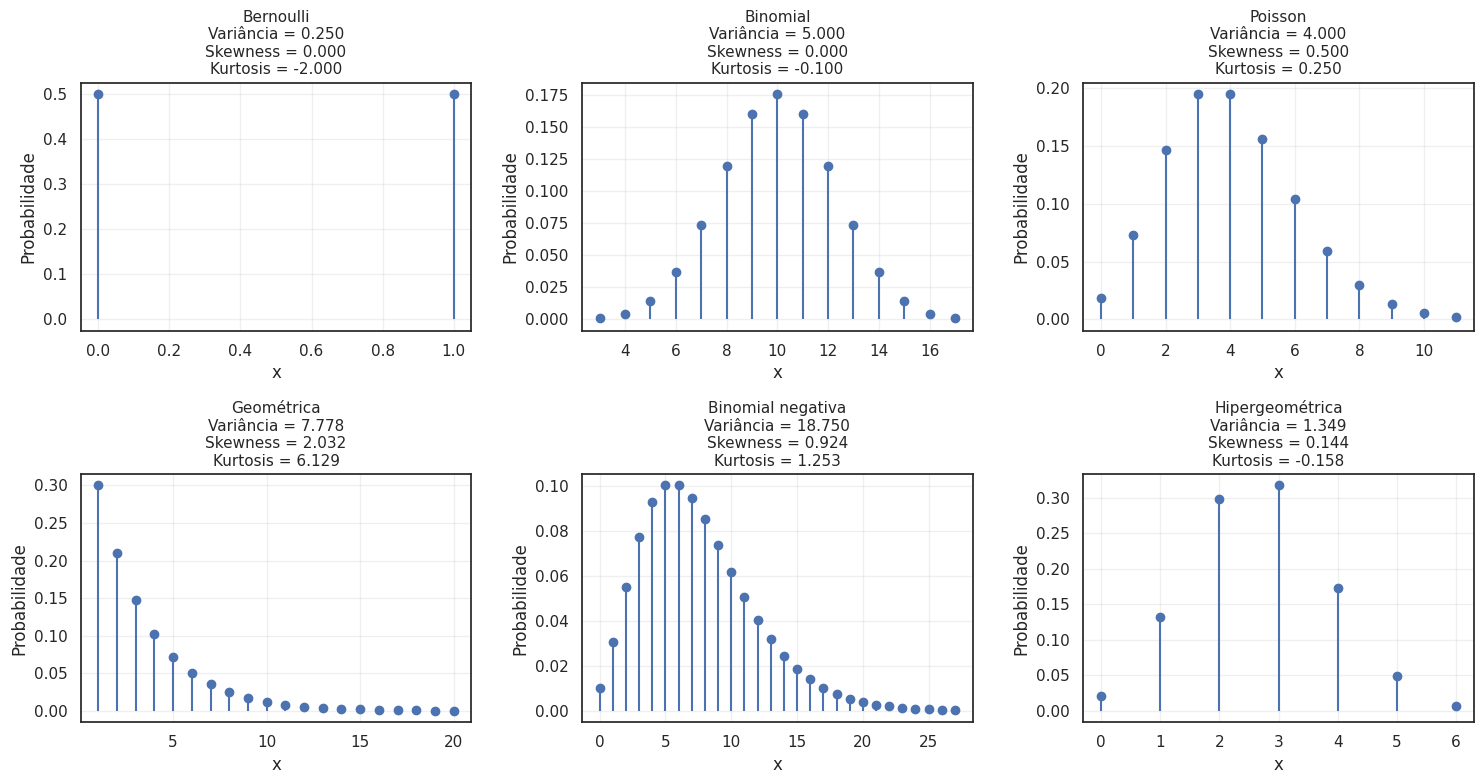

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Criar figura com 2 linhas e 3 colunas
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8)
)

# Distribuições discretas e seus parâmetros
distribuicoes = [
    ("Bernoulli", stats.bernoulli, {"p": 0.5}),
    ("Binomial", stats.binom, {"n": 20, "p": 0.5}),
    ("Poisson", stats.poisson, {"mu": 4}),
    ("Geométrica", stats.geom, {"p": 0.3}),
    ("Binomial negativa", stats.nbinom, {"n": 5, "p": 0.4}),
    ("Hipergeométrica", stats.hypergeom, {"M": 30, "n": 10, "N": 8})
]

# Fazer cada gráfico
for ax, (nome, dist, params) in zip(
    axes.flat,
    distribuicoes
):

    # Definir os valores possíveis de x
    x = np.arange(
        dist.ppf(0.001, **params),
        dist.ppf(0.999, **params) + 1
    ).astype(int)

    # Probabilidade de cada valor
    y = dist.pmf(x, **params)

    # Calcular média, variância, skewness e kurtosis
    media, variancia, skewness, kurtosis = dist.stats(
        moments='mvsk',
        **params
    )

    # Gráfico
    ax.stem(
        x,
        y,
        basefmt=" "
    )

    # Título
    ax.set_title(
        f"{nome}\n"
        f"Variância = {float(variancia):.3f}\n"
        f"Skewness = {float(skewness):.3f}\n"
        f"Kurtosis = {float(kurtosis):.3f}",
        fontsize=11
    )

    ax.set_xlabel("x")
    ax.set_ylabel("Probabilidade")

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()